# 0823_lsw_001_eda

siemens_aoi 원본 데이터(`data/raw/dataset.csv`, `data/raw/mapping.json`) 구조를 확인하는 탐색적 분석(EDA) 노트북입니다.

## 1. 설정과 라이브러리

In [1]:
import json
from pathlib import Path

import pandas as pd

EXPERIMENT_ID = "0823_lsw_001_eda"
DATA_DIR = Path("../data/raw")

## 2. 데이터 로딩

원본 파일은 수정하지 않고 읽기만 합니다. `dataset.csv`는 약 330MB로 로딩에 다소 시간이 걸릴 수 있습니다.

In [2]:
df = pd.read_csv(DATA_DIR / "dataset.csv", index_col=0)

with open(DATA_DIR / "mapping.json", encoding="utf-8") as f:
    inspection_type_mapping = json.load(f)

print("shape:", df.shape)
df.dtypes.value_counts()

shape: (440274, 77)


float64    70
int64       6
str         1
Name: count, dtype: int64

## 3. 스키마 및 결측치 확인

In [3]:
missing_counts = df.isna().sum()
missing_counts[missing_counts > 0].sort_values(ascending=False)

Series([], dtype: int64)

## 4. 라벨 및 검사유형 분포

`class`(0=false call, 1=true defect)와 `inspection_type`(0~4)의 분포, 그리고 검사유형별 클래스 불균형 정도를 확인합니다.

In [4]:
print("class distribution:")
print(df["class"].value_counts().sort_index())

print("\ninspection_type distribution:")
print(df["inspection_type"].value_counts().sort_index())

pd.crosstab(df["inspection_type"], df["class"], normalize="index")

class distribution:
class
0    435652
1      4622
Name: count, dtype: int64

inspection_type distribution:


inspection_type
0     97053
1     57673
2    128174
3    151931
4      5443
Name: count, dtype: int64


class,0,1
inspection_type,,
0,0.996723,0.003277
1,0.972639,0.027361
2,0.989499,0.010501
3,0.991569,0.008431
4,0.981812,0.018188


## 5. mapping.json 기반 유효 컬럼 확인

`inspection_type`마다 실제로 유효한 `inspection_feat` 컬럼 수가 다릅니다 (자세한 내용은 `docs/lsw/siemens_aoi_v2/notes.md` 참고).

In [5]:
for inspection_type, valid_columns in inspection_type_mapping.items():
    print(f"inspection_type {inspection_type}: {len(valid_columns)}개 유효 컬럼")

inspection_type 0: 44개 유효 컬럼
inspection_type 1: 52개 유효 컬럼
inspection_type 2: 65개 유효 컬럼
inspection_type 3: 65개 유효 컬럼
inspection_type 4: 21개 유효 컬럼


## 7. mapping.json 기반 상수열 확인

`inspection_type`별 유효 `inspection_feat` 컬럼만 골라서, 그 안에서 값이 전혀 변하지 않는(상수) 컬럼이 있는지 확인합니다. 무효 컬럼까지 포함해서 상수열을 판단하면 "해당없음 0"이 상수처럼 보여 결과가 왜곡되므로, 반드시 `mapping.json` 기준 유효 컬럼만 봅니다.

In [6]:
feat_cols = [c for c in df.columns if c.startswith("inspection_feat")]

constant_cols_by_type = {}
for inspection_type, valid_columns in inspection_type_mapping.items():
    subset = df.loc[df["inspection_type"] == int(inspection_type), valid_columns]
    nunique = subset.nunique()
    constant_cols = nunique[nunique <= 1].index.tolist()
    constant_cols_by_type[inspection_type] = constant_cols
    print(f"inspection_type {inspection_type}: 유효 컬럼 {len(valid_columns)}개 중 상수열 {len(constant_cols)}개")

constant_cols_by_type

inspection_type 0: 유효 컬럼 44개 중 상수열 7개


inspection_type 1: 유효 컬럼 52개 중 상수열 28개


inspection_type 2: 유효 컬럼 65개 중 상수열 45개


inspection_type 3: 유효 컬럼 65개 중 상수열 46개
inspection_type 4: 유효 컬럼 21개 중 상수열 8개


{'0': ['inspection_feat1',
  'inspection_feat2',
  'inspection_feat16',
  'inspection_feat17',
  'inspection_feat18',
  'inspection_feat19',
  'inspection_feat22'],
 '1': ['inspection_feat16',
  'inspection_feat17',
  'inspection_feat18',
  'inspection_feat20',
  'inspection_feat21',
  'inspection_feat22',
  'inspection_feat40',
  'inspection_feat41',
  'inspection_feat42',
  'inspection_feat43',
  'inspection_feat44',
  'inspection_feat45',
  'inspection_feat46',
  'inspection_feat47',
  'inspection_feat49',
  'inspection_feat53',
  'inspection_feat54',
  'inspection_feat55',
  'inspection_feat56',
  'inspection_feat58',
  'inspection_feat59',
  'inspection_feat71',
  'inspection_feat72',
  'inspection_feat78',
  'inspection_feat93',
  'inspection_feat94',
  'inspection_feat95',
  'inspection_feat96'],
 '2': ['inspection_feat2',
  'inspection_feat6',
  'inspection_feat13',
  'inspection_feat16',
  'inspection_feat17',
  'inspection_feat21',
  'inspection_feat23',
  'inspection_feat24'

## 8. 결측치 상세 분석

컬럼 단위 결측치 개수만으로는 결측이 특정 `inspection_type`이나 `class`에 쏠려 있는지 알 수 없습니다. 행 단위로 결측 개수를 세고, `inspection_type`/`class`별 결측 발생 비율을 확인합니다. 결측이 라벨과 상관관계가 있다면(informative missingness) 단순 삭제/평균 대치보다 신중한 처리 규칙이 필요합니다.

In [7]:
row_missing_count = df.isna().sum(axis=1)

print("행당 결측 컬럼 수 분포:")
print(row_missing_count.describe())
print(f"\n결측이 1개 이상인 행 비율: {(row_missing_count > 0).mean():.4%}")

has_missing = row_missing_count > 0
print("\ninspection_type별 결측 있는 행 비율:")
pd.crosstab(df["inspection_type"], has_missing, normalize="index")

행당 결측 컬럼 수 분포:
count    440274.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
dtype: float64

결측이 1개 이상인 행 비율: 0.0000%

inspection_type별 결측 있는 행 비율:


col_0,False
inspection_type,
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [8]:
print("class별 결측 있는 행 비율:")
pd.crosstab(df["class"], has_missing, normalize="index")

class별 결측 있는 행 비율:


col_0,False
class,
0,1.0
1,1.0


결측이 `mapping.json` 상 "해당없음" 컬럼(무효 컬럼)에서 발생하는지, 아니면 실제로 유효한 측정 컬럼에서도 발생하는지 확인합니다. 만약 무효 컬럼이 0이 아니라 NaN으로 채워져 있다면, `notes.md`에 기록된 "무효 컬럼은 0으로 채워진다"는 가정을 수정해야 합니다.

In [9]:
missing_location = []
for inspection_type, valid_columns in inspection_type_mapping.items():
    rows = df[df["inspection_type"] == int(inspection_type)]
    invalid_columns = [c for c in feat_cols if c not in valid_columns]

    missing_in_valid = rows[valid_columns].isna().sum().sum()
    missing_in_invalid = rows[invalid_columns].isna().sum().sum()
    zero_in_invalid = (rows[invalid_columns] == 0).sum().sum()

    missing_location.append({
        "inspection_type": inspection_type,
        "n_rows": len(rows),
        "missing_in_valid_cols": missing_in_valid,
        "missing_in_invalid_cols": missing_in_invalid,
        "zero_in_invalid_cols": zero_in_invalid,
        "invalid_cells_total": len(rows) * len(invalid_columns),
    })

pd.DataFrame(missing_location).set_index("inspection_type")

,n_rows,missing_in_valid_cols,missing_in_invalid_cols,zero_in_invalid_cols,invalid_cells_total
inspection_type,,,,,
0,97053,0,0,1552849,2523378
1,57673,0,0,461392,1038114
2,128174,0,0,0,640870
3,151931,0,0,0,759655
4,5443,0,0,193286,266707


## 9. 값 범위(이상치) 확인

`inspection_feat*`는 0~1로 정규화되어 있다고 알려져 있습니다(`notes.md` 참고). 이 범위를 벗어나는 값이 있는지 컬럼별 min/max로 확인합니다.

In [10]:
feat_range = df[feat_cols].agg(["min", "max"]).T
out_of_range = feat_range[(feat_range["min"] < 0) | (feat_range["max"] > 1)]

print(f"0~1 범위를 벗어나는 컬럼 수: {len(out_of_range)} / {len(feat_cols)}")
out_of_range

0~1 범위를 벗어나는 컬럼 수: 0 / 70


,min,max


## 10. 중복행 확인

완전히 동일한 행(모든 컬럼 값이 같은 행)이 있는지 확인합니다. `timestamp`가 같은 행은 같은 PCB의 서로 다른 납땜점이라 정상이지만, 모든 컬럼까지 동일하면 데이터 품질 문제일 수 있습니다.

In [11]:
n_dup = df.duplicated().sum()
print(f"완전 중복 행 수: {n_dup} ({n_dup / len(df):.4%})")

완전 중복 행 수: 8752 (1.9879%)


## 11. 시간 커버리지 확인

`timestamp` 범위와 일자별 데이터 수, 일자별 true defect 비율 추이를 확인합니다. 132일 동안 데이터가 고르게 있는지, 시간에 따라 라벨 비율이 크게 흔들리는지(향후 drift 분석의 사전 신호) 가볍게 확인합니다.

In [12]:
ts = pd.to_datetime(df["timestamp"])
print("timestamp 범위:", ts.min(), "~", ts.max())

daily_counts = ts.dt.floor("D").value_counts().sort_index()
print("데이터가 존재하는 일자 수:", daily_counts.shape[0])
daily_counts.describe()

timestamp 범위: 1970-06-23 03:58:55+00:00 ~ 1970-11-02 14:21:28+00:00
데이터가 존재하는 일자 수: 101


count      101.000000
mean      4359.148515
std       4704.607608
min         12.000000
25%        905.000000
50%       2993.000000
75%       5416.000000
max      23046.000000
Name: count, dtype: float64

C:\Users\ajou\Desktop\manufacturing_AI\siemens_aoi_ML_practice\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ajou\Desktop\manufacturing_AI\siemens_aoi_ML_practice\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ajou\Desktop\manufacturing_AI\siemens_aoi_ML_practice\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ajou\Desktop\manufacturing_AI\siemens_aoi_ML_practice\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ajou\Deskt

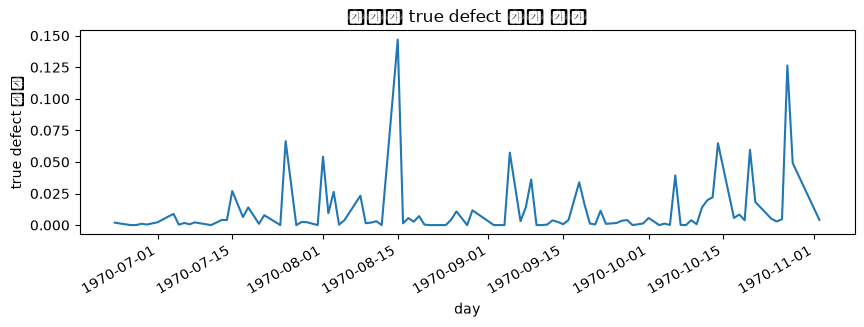

In [13]:
import matplotlib.pyplot as plt

daily_defect_rate = df.assign(day=ts.dt.floor("D")).groupby("day")["class"].mean()

fig, ax = plt.subplots(figsize=(10, 3))
daily_defect_rate.plot(ax=ax)
ax.set_ylabel("true defect 비율")
ax.set_title("일자별 true defect 비율 추이")
plt.show()

## 12. 무효 컬럼(해당없음) 값 패턴 추가 확인

위 8절 결과, `inspection_type` 0/1/4는 무효 컬럼 상당수가 0으로 채워지지만, **`inspection_type` 2/3는 무효 컬럼이 0인 셀이 전혀 없었습니다.** 즉 `notes.md`의 "무효 컬럼은 0으로 채워진다"는 가정은 2/3 유형에는 맞지 않습니다. 0이 아니라면 어떤 값 분포를 갖는지 집계 통계로만(원본 행 노출 없이) 확인합니다.

In [14]:
for inspection_type in ["2", "3"]:
    valid_columns = inspection_type_mapping[inspection_type]
    invalid_columns = [c for c in feat_cols if c not in valid_columns]
    rows = df[df["inspection_type"] == int(inspection_type)]

    invalid_stats = rows[invalid_columns].agg(["min", "max", "mean", "std"]).T
    n_nonzero_const = (invalid_stats["std"] == 0).sum()
    print(f"inspection_type {inspection_type}: 무효 컬럼 {len(invalid_columns)}개 중 "
          f"행 전체가 상수(0 아닌 단일값 포함)인 컬럼 {n_nonzero_const}개")
    print(invalid_stats.describe().loc[["min", "mean", "max"]])
    print()

inspection_type 2: 무효 컬럼 5개 중 행 전체가 상수(0 아닌 단일값 포함)인 컬럼 2개
           min       max      mean           std
min   0.480879  0.480879  0.480879  0.000000e+00
mean  0.538081  0.538081  0.538081  5.551137e-17
max   0.604758  0.604758  0.604758  1.110227e-16

inspection_type 3: 무효 컬럼 5개 중 행 전체가 상수(0 아닌 단일값 포함)인 컬럼 3개
           min       max      mean           std
min   0.480879  0.480879  0.480879  0.000000e+00
mean  0.538081  0.538081  0.538081  4.440907e-17
max   0.604758  0.604758  0.604758  1.110227e-16



## 13. 결론 및 다음 단계

### 핵심 관찰 사항

- **NaN 결측치는 0건.** `df.isna().sum()`이 모든 컬럼에서 0이며, 행 단위로도 결측이 전혀 없다. 이슈에서 말한 "결측치 포함 대량 행"은 실제 NaN이 아니라, `mapping.json` 기준 해당 `inspection_type`에 유효하지 않은(무의미한) `inspection_feat` 컬럼을 가리키는 것으로 재해석해야 한다.
- **"무효 컬럼은 0으로 채워진다"는 기존 가정(`notes.md`)은 일부만 맞다.** `inspection_type` 0/1/4는 무효 컬럼 셀 중 44~72%가 0이지만, **`inspection_type` 2/3는 무효 컬럼에 0이 단 하나도 없고** 대신 좁은 범위(약 0.48~0.60)의 (준)상수 값으로 채워져 있다. → 전처리에서 "값이 0이면 무효"처럼 값 기반으로 무효 컬럼을 추론하면 안 되고, 반드시 `mapping.json`으로 명시적 마스킹해야 한다.
- **유효 컬럼 중에도 상수열이 매우 많다.** `inspection_type`별 유효 컬럼 중 분산이 0인(nunique<=1) 컬럼 비율: type0 7/44(16%), type1 28/52(54%), type2 45/65(69%), type3 46/65(71%), type4 8/21(38%). 정보량이 없는 컬럼이 절반 이상인 유형도 있어, 모델링 전 type별 상수열 제거가 유의미한 차원 축소가 될 것으로 보인다.
- **값 범위 이상치는 없음.** 70개 `inspection_feat` 전부 [0, 1] 범위 안에 있다.
- **완전 중복행이 8,752건(1.99%) 존재.** 우연히 발생하기엔 적지 않은 비율이라, 다음 실험에서 원인(중복 로깅 vs 실제 반복 측정)을 확인하고 제거 여부를 결정해야 한다.
- **시간 커버리지가 불균등하다.** timestamp는 132일 구간에 걸쳐 있지만 실제 데이터가 있는 날은 101일뿐이고(약 31일 공백), 일별 건수도 12~23,046건으로 편차가 크다(표준편차가 평균보다 큼). 시간 기반 분할이나 drift 분석 윈도우 설계 시 이 공백/편차를 고려해야 한다.
- **클래스 불균형**은 `notes.md`에 기록된 것과 대체로 일치(type별 0.33~2.74%).

### 다음 실험에서 다뤄야 할 항목 (전처리 규칙 설계, 관련 이슈: 데이터 전처리 규칙 설계)

1. `mapping.json` 기반 명시적 마스킹을 전처리 1순위 규칙으로 고정 (값이 0인지 여부로 판단하지 않음).
2. `inspection_type`별 상수열 제거 규칙 확정 (기준: 해당 유형의 유효 컬럼 중 `nunique <= 1`).
3. 완전 중복행 8,752건의 원인 조사 후 제거 여부 결정.
4. 시간 공백(약 31일)과 일별 건수 편차를 반영한 train/val/test 시간 분할 규칙 설계.
5. 위 근거를 버전 명시 문서(예: `data_preprocessing_v1.md`)로 정리 — 문서 위치와 팀 리뷰는 별도로 협의.
